In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
df.shape

(891, 12)

In [60]:
df.ndim

2

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data Preprocing

In [62]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [63]:
del df['Cabin']

In [64]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [65]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [66]:
df.dropna(axis=0, inplace=True)

In [67]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [68]:
df.shape

(712, 11)

In [69]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [70]:
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

In [71]:
df.shape

(712, 8)

In [72]:
# Treat the categorical variable
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [73]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [74]:
x = df.iloc[:,1:]
y = df['Survived']
y.value_counts()

Survived
0    424
1    288
Name: count, dtype: int64

In [75]:
# Balancing the data in the y variable prediction variable
# SMOTE (method) -> synthetic minority oversampling technique

In [76]:
!pip3 install imblearn

In [77]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy='minority')
x,y = sm.fit_resample(x,y)

In [78]:
y.value_counts()

Survived
0    424
1    424
Name: count, dtype: int64

In [79]:
len(x)

848

In [80]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.000000,1,0,7.250000,2
1,1,0,38.000000,1,0,71.283300,0
2,3,0,26.000000,0,0,7.925000,2
3,1,0,35.000000,1,0,53.100000,2
4,3,1,35.000000,0,0,8.050000,2
...,...,...,...,...,...,...,...
843,2,0,50.591403,0,0,11.150543,2
844,3,1,32.000000,0,0,56.495800,2
845,3,0,19.406505,0,0,7.614972,0
846,1,0,20.080127,0,1,79.441987,2


In [81]:
# Finding the data is a noisy data or not....
# when there is a noisy data we will use the ensamble tecnique..... or SVM (support vector machine)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
comp = pca.fit_transform(x)

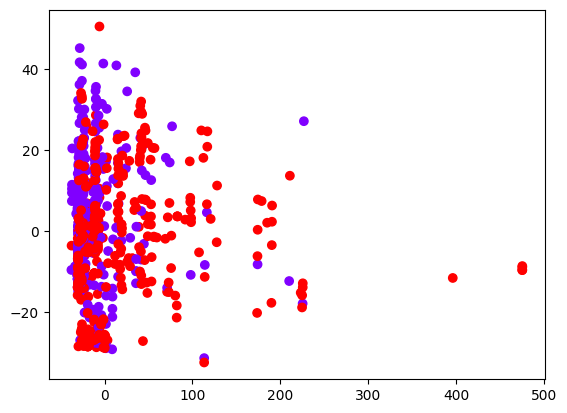

In [82]:
plt.scatter(comp[:,0],comp[:,1],cmap = 'rainbow',c = y)
plt.show()

In [83]:
y.value_counts()

Survived
0    424
1    424
Name: count, dtype: int64

In [84]:
# We can go by ensamble technique, svm , ann
# Handling the noise data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1,shuffle=True)

In [85]:
# Model Building
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [86]:
dt.score(x_train,y_train)

0.9911504424778761

In [87]:
dt.score(x_test,y_test)

0.8

In [88]:
# Using Ensamble technics because the model is an overfited model use ensamble technique
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [89]:
print(rf.score(x_train,y_train))
print(rf.score(x_test,y_test))

0.9911504424778761
0.8411764705882353


In [ ]:
rf1 = RandomForestClassifier(max_depth=5, # Help to avoid the overfitting.....
                             n_estimators=50)
rf1.fit(x_train,y_train)

RandomForestClassifier(max_depth=5, n_estimators=50)

In [91]:
print(rf1.score(x_train,y_train))
print(rf1.score(x_test,y_test))

0.8702064896755162
0.8470588235294118


In [92]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [93]:
# For underfitting model we can go with the ensemble import AdaBoostClassifier